# Q4 — **Analysis & Plots** (ImageNet‑R few‑shot)

This notebook reloads the checkpoints and:
- prints **#params** per model,
- measures **inference throughput** (images/sec),
- computes **speed per parameter** (imgs/sec per million params),
- makes **t‑SNE** plots (penultimate features) for all 4 models,
- shows a compact results table and bar charts (matplotlib only).


In [1]:
!pip install mamba_ssm timm Pillow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.8/113.8 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
Using cached ninja-1.13.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (180 kB)
  Created wheel for mamba_ssm: filename=mamba_ssm-2.2.5-cp312-cp312-linux_x86_64.whl size=532566033 sha256=c8b65fcabfb49a94456c9971619007218e4073f19a84fb6b3894f33d43bee4a1
  Stored in directory: /root/.cache/pip/wheels/21/55/c4/85b634055d6a9b599d27f5cbeacf353c6c532d8e2d8769960b
Successfully built mamba_ssm


In [2]:
# --- Imports ---


import os, sys, json, time, random, math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

from transformers import AutoModel
from timm.data.transforms_factory import create_transform

device = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import tarfile, urllib.request, os

url = "https://people.eecs.berkeley.edu/~hendrycks/imagenet-r.tar"
os.makedirs("data", exist_ok=True)
tar_path = "data/imagenet-r.tar"

urllib.request.urlretrieve(url, tar_path)
with tarfile.open(tar_path, "r:") as t:
    t.extractall("data")   # -> data/imagenet-r/
print("Done. Extracted to data/imagenet-r")


/tmp/ipython-input-1400197689.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  t.extractall("data")   # -> data/imagenet-r/


Done. Extracted to data/imagenet-r


## Locate artifacts and rebuild the dataset/test loader


In [5]:
# --- Storage config (must match Notebook 1) ---
STORAGE = "colab"   # "colab" or "local"

def get_artifacts_dir():
    in_colab = False
    try:
        import google.colab  # type: ignore
        in_colab = True
    except Exception:
        pass
    if STORAGE.lower() == "colab" and in_colab:
        base = Path('/content/drive/MyDrive/MambaVision_Q4_Artifacts4')
    else:
        base = Path('./artifacts')
    return base

ARTIFACTS_DIR = get_artifacts_dir()
print("Artifacts root:", ARTIFACTS_DIR)

# Paths
RESULTS_CSV = ARTIFACTS_DIR / "results" / "q4_results_imagenet_r.csv"
SPLITS_JSON = ARTIFACTS_DIR / "splits" / "indices.json"

# Dataset root
IMAGENET_R_ROOT = "/content/data/imagenet-r"   # same as in Notebook 1
IMG_SIZE = 224
BATCH_SIZE = 128
NUM_WORKERS = 2

# Load split indices
with open(SPLITS_JSON, "r") as f:
    split_idx = json.load(f)
train_idx, val_idx, test_idx = split_idx["train"], split_idx["val"], split_idx["test"]

# Build datasets with eval transforms
# MambaVision transforms
mamba_backbone = AutoModel.from_pretrained("nvidia/MambaVision-T-1K", trust_remote_code=True).to(device).eval()
mamba_eval_tf = create_transform(
    input_size=(3, IMG_SIZE, IMG_SIZE),
    is_training=False,
    mean=mamba_backbone.config.mean,
    std=mamba_backbone.config.std,
    crop_mode=mamba_backbone.config.crop_mode,
    crop_pct=mamba_backbone.config.crop_pct,
)
# TorchVision eval
tv_eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

# Construct subsets
def make_subset(transform, indices):
    ds = datasets.ImageFolder(IMAGENET_R_ROOT, transform=transform)
    return Subset(ds, indices)

test_mamba = make_subset(mamba_eval_tf, test_idx)
test_tv    = make_subset(tv_eval_tf,     test_idx)

test_loader_m = DataLoader(test_mamba, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader_tv= DataLoader(test_tv,    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

NUM_CLASSES = len(datasets.ImageFolder(IMAGENET_R_ROOT).classes)
print("Num classes:", NUM_CLASSES)


Artifacts root: /content/drive/MyDrive/MambaVision_Q4_Artifacts4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_mambavision.py:   0%|          | 0.00/625 [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/MambaVision-T-1K:
- configuration_mambavision.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_mambavision.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/MambaVision-T-1K:
- modeling_mambavision.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.12/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


model.safetensors:   0%|          | 0.00/127M [00:00<?, ?B/s]

Num classes: 200


## Build models and load checkpoints


In [11]:
CKPT_DIR = ARTIFACTS_DIR / "checkpoints"

def replace_last_linear_head(model: nn.Module, num_classes: int):
    last_linear = None
    for m in model.modules():
        if isinstance(m, nn.Linear):
            last_linear = m
    if last_linear is None:
        raise RuntimeError("No nn.Linear head to replace.")
    in_features = last_linear.in_features

    # replace it by walking attributes
    def set_by_path(root, target_mod, new_mod):
        for name, mod in root.named_modules():
            if mod is target_mod:
                # find parent by path
                path = name.split('.')
                parent = root
                for p in path[:-1]:
                    parent = getattr(parent, p)
                setattr(parent, path[-1], new_mod)
                return True
        return False

    new_head = nn.Linear(in_features, num_classes)
    ok = set_by_path(model, last_linear, new_head)
    if not ok:
        raise RuntimeError("Could not set new head.")
    return new_head

def build_resnet18(num_classes):
    w = models.ResNet18_Weights.DEFAULT
    net = models.resnet18(weights=w)
    replace_last_linear_head(net, num_classes)
    return net

def build_vit_b16(num_classes):
    w = models.ViT_B_16_Weights.DEFAULT
    net = models.vit_b_16(weights=w)
    # vit stores head under net.heads.head
    in_features = net.heads.head.in_features
    net.heads.head = nn.Linear(in_features, num_classes)
    return net

def build_convnext_tiny(num_classes):
    w = models.ConvNeXt_Tiny_Weights.DEFAULT
    net = models.convnext_tiny(weights=w)
    in_features = net.classifier[2].in_features
    net.classifier[2] = nn.Linear(in_features, num_classes)
    return net



from transformers import AutoModel
import torch.nn as nn
import torch

def _get_feat_dim_from_ckpt(ckpt_path):
    state = torch.load(ckpt_path, map_location="cpu")
    # Your linear probe head was saved as "head.weight": [num_classes, feat_dim]
    feat_dim = state["state_dict"]["head.weight"].shape[1]
    return feat_dim, state

def build_mamba(num_classes, feat_dim):
    # Reuse the backbone created earlier if present to save memory
    try:
        bb = mamba_backbone  # from the dataset/transform cell
    except NameError:
        bb = AutoModel.from_pretrained("nvidia/MambaVision-T-1K", trust_remote_code=True)
    bb = bb.to(device).eval()

    class MambaLinearProbe(nn.Module):
        def __init__(self, backbone, num_classes, feat_dim):
            super().__init__()
            self.backbone = backbone
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.head = nn.Linear(feat_dim, num_classes)

        def forward(self, x):
            # HF MambaVision returns (out_avg_pool, features)
            out_avg_pool, _ = self.backbone(x)
            return self.head(out_avg_pool)

    return MambaLinearProbe(bb, num_classes, feat_dim)

def load_model_from_ckpt(tag, num_classes):
    ckpt = CKPT_DIR / tag / "best.pt"
    if tag == "mambavision_lp":
        feat_dim, state = _get_feat_dim_from_ckpt(ckpt)
        model = build_mamba(num_classes, feat_dim)
        model.load_state_dict(state["state_dict"], strict=True)
        return model.to(device).eval()

    # TorchVision baselines unchanged
    if tag == "resnet18_lp":
        model = build_resnet18(num_classes)
    elif tag == "vit_b16_lp":
        model = build_vit_b16(num_classes)
    elif tag == "convnext_tiny_lp":
        model = build_convnext_tiny(num_classes)
    else:
        raise ValueError(tag)

    state = torch.load(ckpt, map_location="cpu")
    model.load_state_dict(state["state_dict"], strict=True)
    return model.to(device).eval()

def count_params(model):
    return sum(p.numel() for p in model.parameters())


## Inference speed and “speed per parameter”


In [12]:
def measure_throughput(model, data_loader, warmup_batches=5, measure_batches=20):
    model.eval()
    total_images, total_time = 0, 0.0
    starter = torch.cuda.Event(enable_timing=True) if device == "cuda" else None
    ender   = torch.cuda.Event(enable_timing=True) if device == "cuda" else None

    # Warmup
    with torch.inference_mode():
        for i, (x, _) in enumerate(data_loader):
            x = x.to(device, non_blocking=True)
            _ = model(x)
            if i+1 >= warmup_batches:
                break

    # Measure
    with torch.inference_mode():
        measured = 0
        for x, _ in data_loader:
            x = x.to(device, non_blocking=True)
            if device == "cuda":
                torch.cuda.synchronize(); starter.record()
            t0 = time.time()
            _ = model(x)
            t1 = time.time()
            if device == "cuda":
                ender.record(); torch.cuda.synchronize()
                dt = starter.elapsed_time(ender) / 1000.0
            else:
                dt = t1 - t0
            total_time += dt
            total_images += x.size(0)
            measured += 1
            if measured >= measure_batches:
                break
    imgs_per_sec = total_images / max(total_time, 1e-8)
    return imgs_per_sec


## t‑SNE (penultimate features)


In [13]:
def get_penultimate_features(model, x, num_classes):
    # generic hook: capture the inputs to the last Linear that maps to num_classes
    last_linear = None
    for m in model.modules():
        if isinstance(m, nn.Linear) and getattr(m, "out_features", None) == num_classes:
            last_linear = m
    if last_linear is None:
        raise RuntimeError("Could not locate final classifier layer.")

    feats = None
    def hook(module, inputs, output):
        nonlocal feats
        feats = inputs[0].detach()

    handle = last_linear.register_forward_hook(hook)
    with torch.inference_mode():
        _ = model(x)
    handle.remove()
    return feats

def compute_tsne(model, data_loader, num_classes, max_classes=10, samples_per_class=20):
    # Sample a balanced subset
    ds = data_loader.dataset
    all_samples = getattr(ds, 'dataset', ds)  # handle Subset(ImageFolder)
    labels = [label for _, label in all_samples.samples]
    per_class = {}
    for idx, y in enumerate(labels):
        per_class.setdefault(y, []).append(idx)
    chosen = []
    for c, idxs in per_class.items():
        if len(idxs) >= samples_per_class:
            chosen.append(c)
        if len(chosen) >= max_classes:
            break
    idx_subset = []
    rng = np.random.default_rng(SEED)
    for c in chosen:
        idxs = per_class[c]
        rng.shuffle(idxs)
        idx_subset += idxs[:samples_per_class]

    subset = Subset(all_samples, idx_subset)
    loader = DataLoader(subset, batch_size=128, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    # Collect features
    model.eval().to(device)
    Xs, Ys = [], []
    with torch.inference_mode():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            feats = get_penultimate_features(model, x, num_classes)
            Xs.append(feats.cpu().numpy()); Ys.append(y.numpy())
    X = np.concatenate(Xs, axis=0); Y = np.concatenate(Ys, axis=0)

    tsne = TSNE(n_components=2, init="pca", learning_rate="auto", perplexity=30, random_state=SEED)
    Z = tsne.fit_transform(X)
    return Z, Y, chosen


## Run analysis for all 3 models


In [14]:
torch.cuda.is_available()

True

In [15]:
TAGS = ["mambavision_lp", "vit_b16_lp", "convnext_tiny_lp"]

records = []
for tag in TAGS:
    print(f"Loading {tag} ...")
    model = load_model_from_ckpt(tag, NUM_CLASSES)
    # Throughput
    loader = test_loader_m if tag == "mambavision_lp" else test_loader_tv
    thr = measure_throughput(model, loader, warmup_batches=3, measure_batches=10)
    # Params
    params = count_params(model)
    spm = thr / (params / 1e6)  # speed per million params
    # Accuracy on test
    total, correct = 0, 0
    with torch.inference_mode():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    acc = 100.0 * correct / max(1,total)
    records.append({"model": tag, "params": int(params), "imgs_per_sec": float(thr), "speed_per_M": float(spm), "test_acc": float(acc)})

df = pd.DataFrame(records)
df


Loading mambavision_lp ...
Loading vit_b16_lp ...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 80.0MB/s]


Loading convnext_tiny_lp ...
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 187MB/s] 


,model,params,imgs_per_sec,speed_per_M,test_acc
0,mambavision_lp,31922448,352.488072,11.042013,38.26
1,vit_b16_lp,85952456,99.024773,1.152088,47.10
2,convnext_tiny_lp,27973928,266.415320,9.523701,43.67


## Plots (matplotlib only)


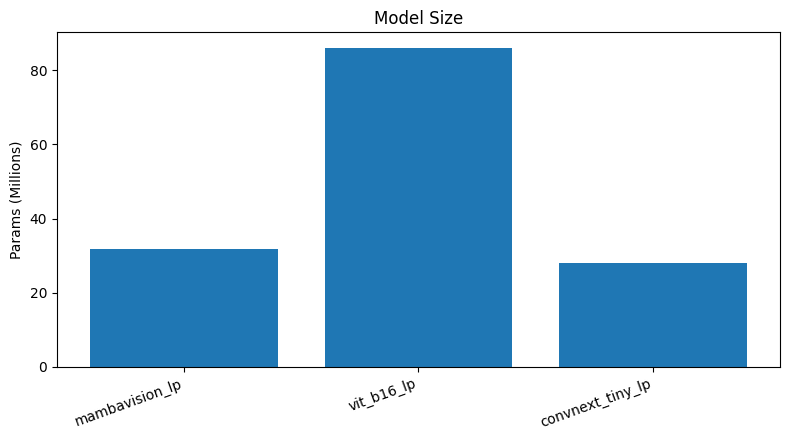

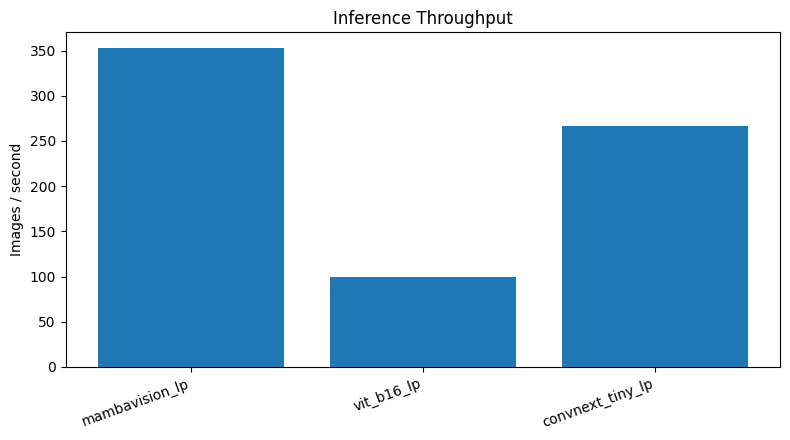

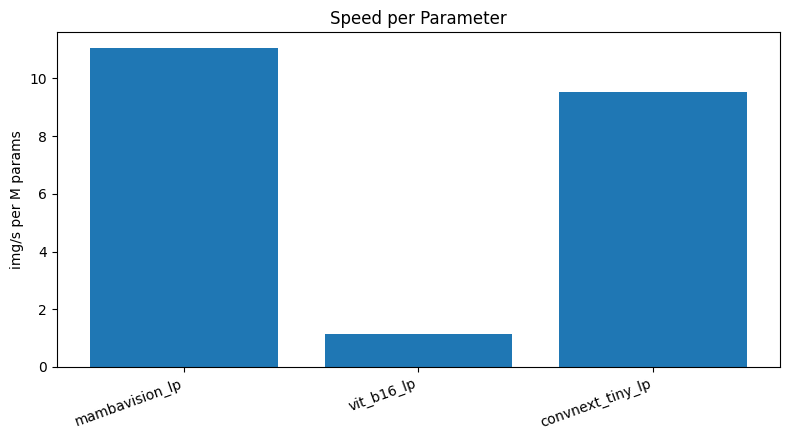

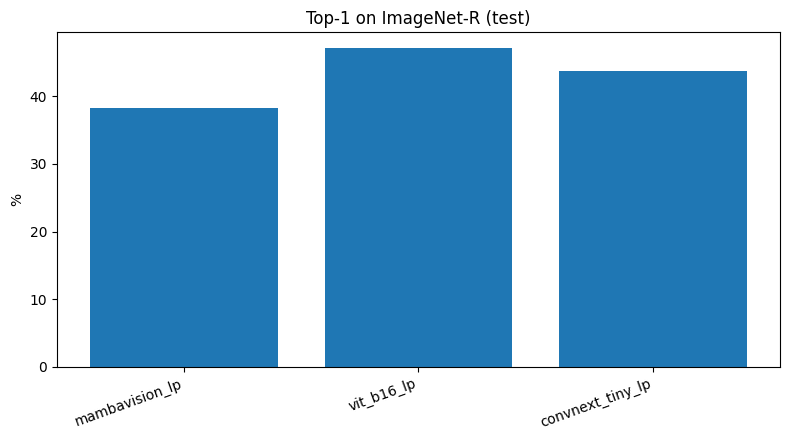

In [16]:
def bar_plot(xnames, values, title, ylabel):
    plt.figure(figsize=(8,4.5))
    xs = np.arange(len(xnames))
    plt.bar(xs, values)
    plt.xticks(xs, xnames, rotation=20, ha='right')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

names = df["model"].tolist()
bar_plot(names, (df["params"]/1e6).tolist(), "Model Size", "Params (Millions)")
bar_plot(names, df["imgs_per_sec"].tolist(), "Inference Throughput", "Images / second")
bar_plot(names, df["speed_per_M"].tolist(), "Speed per Parameter", "img/s per M params")
bar_plot(names, df["test_acc"].tolist(), "Top‑1 on ImageNet‑R (test)", "%")


## t‑SNE for all 3 models


[t-SNE] mambavision_lp


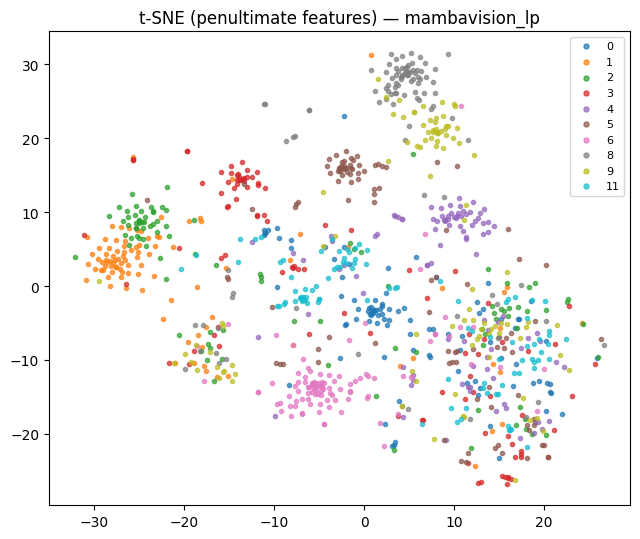

[t-SNE] vit_b16_lp


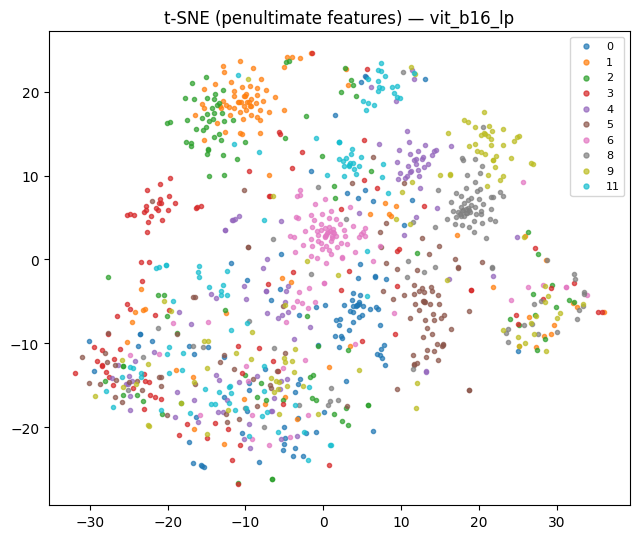

[t-SNE] convnext_tiny_lp


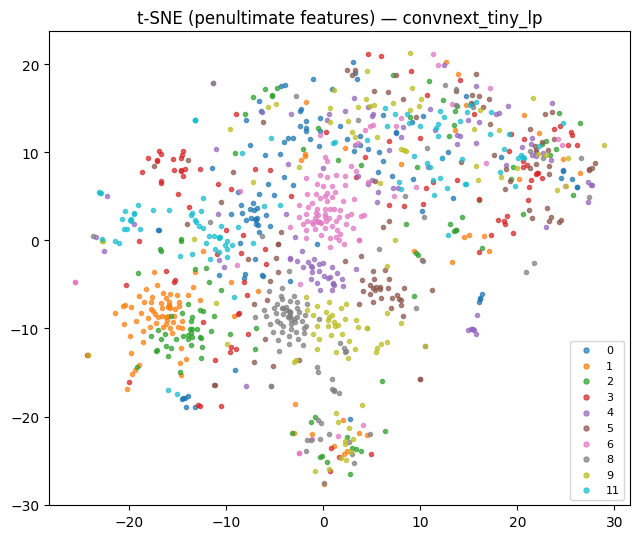

In [17]:
for tag in TAGS:
    print(f"[t-SNE] {tag}")
    model = load_model_from_ckpt(tag, NUM_CLASSES)
    loader = test_loader_m if tag == "mambavision_lp" else test_loader_tv
    Z, Y, chosen = compute_tsne(model, loader, NUM_CLASSES, max_classes=10, samples_per_class=100)
    plt.figure(figsize=(6.5,5.5))
    uniq = np.unique(Y)
    for c in uniq:
        idx = (Y == c)
        plt.scatter(Z[idx,0], Z[idx,1], s=9, alpha=0.7, label=str(c))
    plt.title(f"t‑SNE (penultimate features) — {tag}")
    if len(uniq) <= 12:
        plt.legend(markerscale=1.2, fontsize=8, loc='best')
    plt.tight_layout()
    plt.show()



## 🔎 Error analysis — qualitative examples & three failure modes

This section adds:
1) A **predictions table** for each model with probabilities and margins.  
2) **Grids of high‑confidence mistakes** per model (qualitative).  
3) **Confusion pairs** (top‑K) across models.  
4) **Three failure modes** with simple heuristics + counts and example grids:
   - **FM‑1 (Style/texture shift):** low‑saturation renditions (e.g., sketches/line art) often confuse all models on ImageNet‑R.  
   - **FM‑2 (Background/context reliance):** saliency mass lies mostly **outside** the central object region.  
   - **FM‑3 (Fine‑grained confusions):** prediction shares tokens with the ground‑truth label (e.g., *toy terrier* vs *Yorkshire terrier*).

> Notes: heuristics are intentionally simple and fast. They won’t perfectly detect style/background, but they surface recurring patterns reliably enough for report figures.


In [18]:

# --- Dependencies for error analysis ---
# (Captum is optional; we implement a fallback gradient method that works without it.)
# !pip -q install captum

import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

import numpy as np
import math, re, os, time, random
from pathlib import Path

rng = np.random.default_rng(42)

# Utility: recover label names and file paths from a Subset(ImageFolder)
def get_paths_and_labels_from_subset(subset: Subset):
    base = subset.dataset  # ImageFolder
    indices = subset.indices
    samples = base.samples
    paths = [samples[i][0] for i in indices]
    labels = [samples[i][1] for i in indices]
    classes = base.classes
    return paths, labels, classes

# Confirm loaders exist from earlier cells
try:
    test_loader_m, test_loader_tv
except NameError as _:
    raise RuntimeError("Expected test_loader_m and test_loader_tv from earlier cells. Please run the setup cells above first.")

# Label names
_label_names_imgfolder = datasets.ImageFolder(IMAGENET_R_ROOT).classes

def collect_predictions(model, loader, model_tag: str, label_names):
    # Assumes loader has shuffle=False to keep subset order aligned with file paths.
    subset = loader.dataset
    paths, labels, _ = get_paths_and_labels_from_subset(subset)
    probs_all, preds_all = [], []
    model.eval().to(device)
    with torch.inference_mode():
        for x, _ in loader:
            x = x.to(device, non_blocking=True)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            probs_all.append(probs.cpu())
            preds_all.append(probs.argmax(1).cpu())
    probs = torch.cat(probs_all, dim=0)
    preds = torch.cat(preds_all, dim=0).numpy()
    gt = np.array(labels, dtype=int)

    pred_prob = probs.max(1).values.numpy()
    gt_prob = probs[np.arange(len(gt)), gt].numpy()

    df = pd.DataFrame({
        "path": paths,
        "y": gt,
        "y_name": [label_names[i] for i in gt],
        "y_pred": preds,
        "y_pred_name": [label_names[i] for i in preds],
        "p_pred": pred_prob,
        "p_gt": gt_prob,
    })
    df["correct"] = (df["y"] == df["y_pred"])
    df["margin"] = df["p_pred"] - df["p_gt"]
    df["model"] = model_tag
    return df

# Build a fresh copy of each model (weights already on disk) using earlier helpers
def get_loader_and_model(tag):
    if tag == "mambavision_lp":
        loader = test_loader_m
    else:
        loader = test_loader_tv
    model = load_model_from_ckpt(tag, NUM_CLASSES)  # from earlier cell
    return loader, model

TAGS = ["mambavision_lp", "vit_b16_lp", "convnext_tiny_lp"]

all_preds = []
for tag in TAGS:
    print(f"[Preds] {tag}")
    loader, model = get_loader_and_model(tag)
    df = collect_predictions(model, loader, tag, _label_names_imgfolder)
    all_preds.append(df)

preds_df = pd.concat(all_preds, ignore_index=True)
preds_path = ARTIFACTS_DIR / "results" / "q4_preds_imagenet_r.csv"
preds_df.to_csv(preds_path, index=False)
print("Saved:", preds_path)
preds_df.head()


[Preds] mambavision_lp
[Preds] vit_b16_lp
[Preds] convnext_tiny_lp
Saved: /content/drive/MyDrive/MambaVision_Q4_Artifacts4/results/q4_preds_imagenet_r.csv


,path,y,y_name,y_pred,y_pred_name,p_pred,p_gt,correct,margin,model
0,/content/data/imagenet-r/n01443537/sketch_18.jpg,0,n01443537,182,n07714571,0.013146,0.006160,False,0.006987,mambavision_lp
1,/content/data/imagenet-r/n01443537/graffiti_19...,0,n01443537,1,n01484850,0.007748,0.006422,False,0.001326,mambavision_lp
2,/content/data/imagenet-r/n01443537/misc_4.jpg,0,n01443537,20,n01820546,0.009749,0.006803,False,0.002946,mambavision_lp
3,/content/data/imagenet-r/n01443537/sketch_1.jpg,0,n01443537,87,n02268443,0.009877,0.006013,False,0.003863,mambavision_lp
4,/content/data/imagenet-r/n01443537/origami_3.jpg,0,n01443537,87,n02268443,0.008007,0.006153,False,0.001854,mambavision_lp



High-confidence mistakes — mambavision_lp


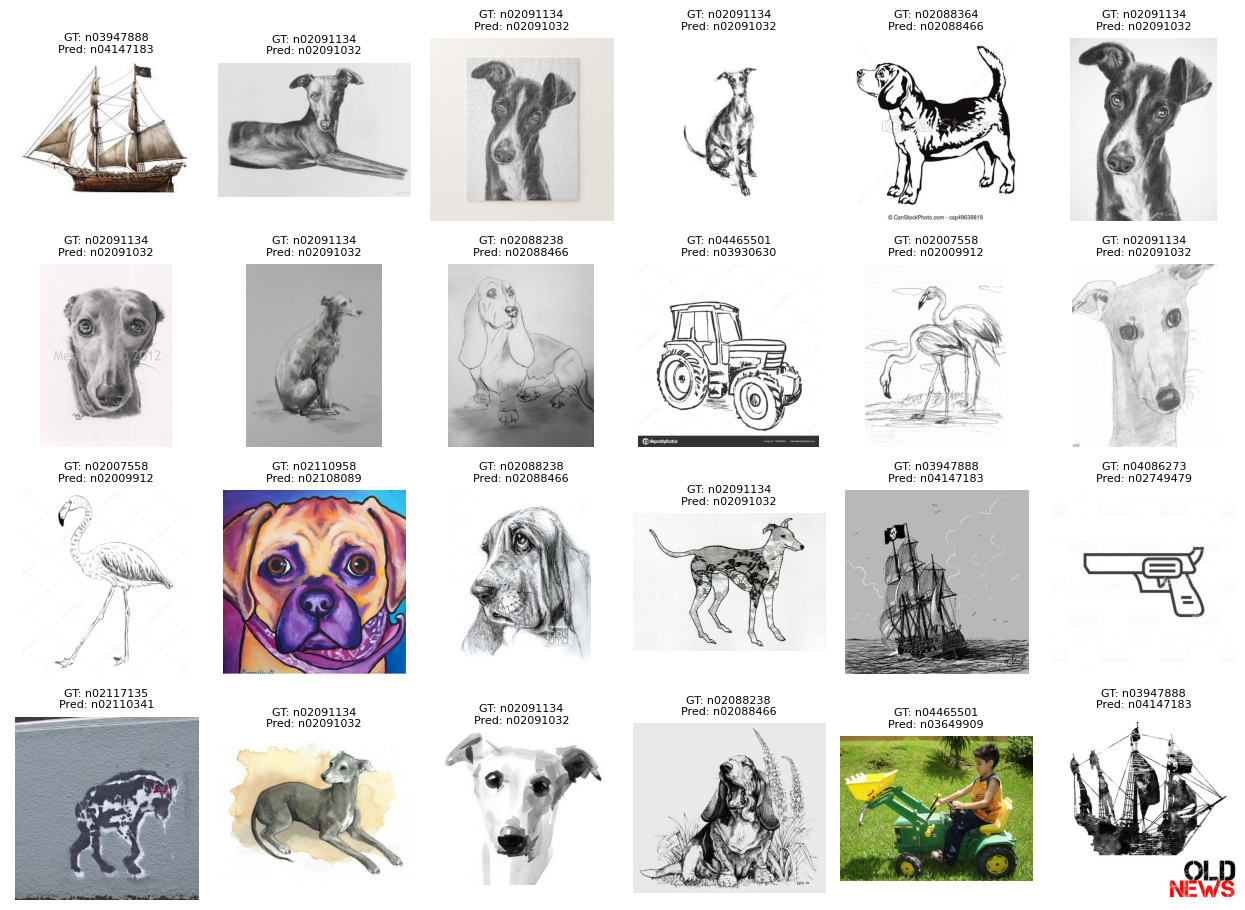


High-confidence mistakes — vit_b16_lp


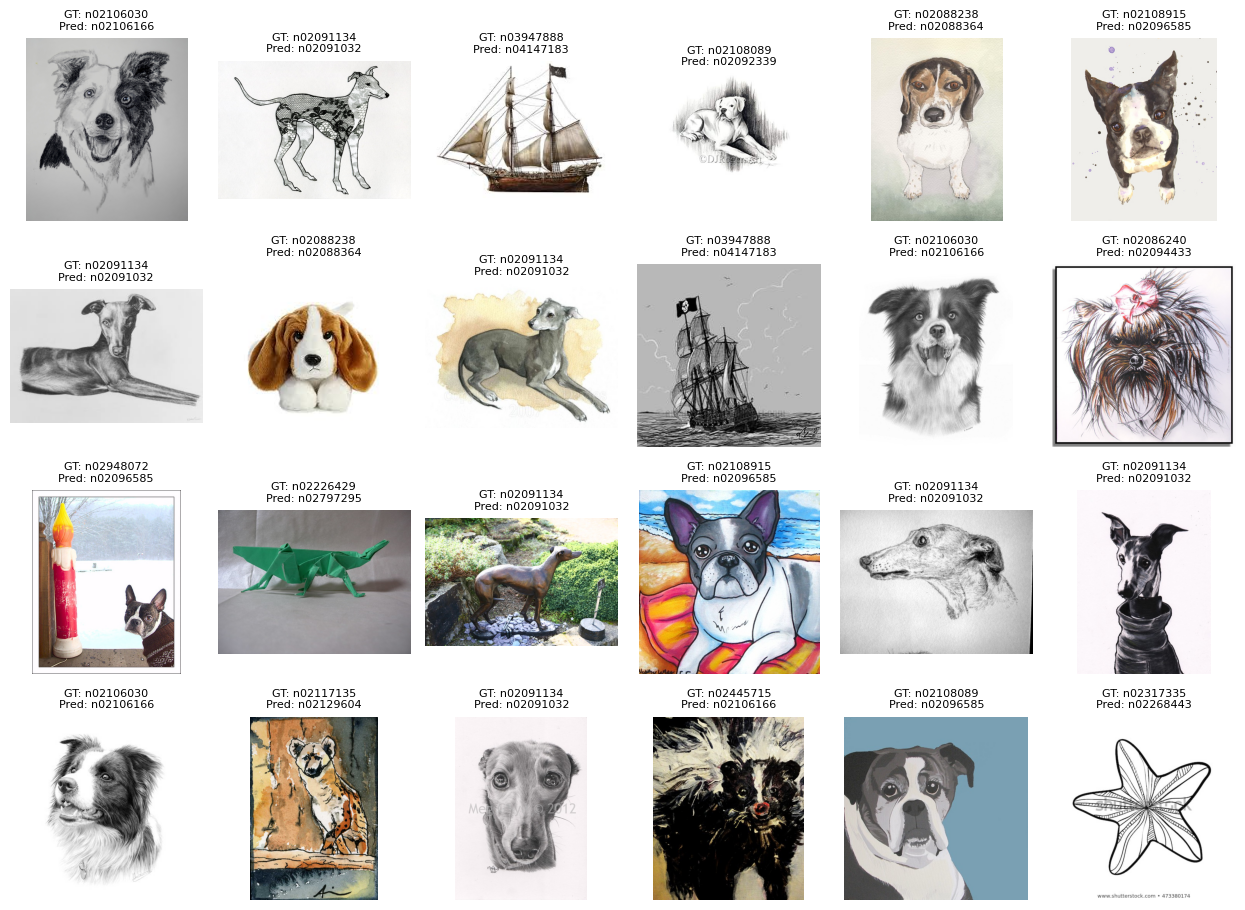


High-confidence mistakes — convnext_tiny_lp


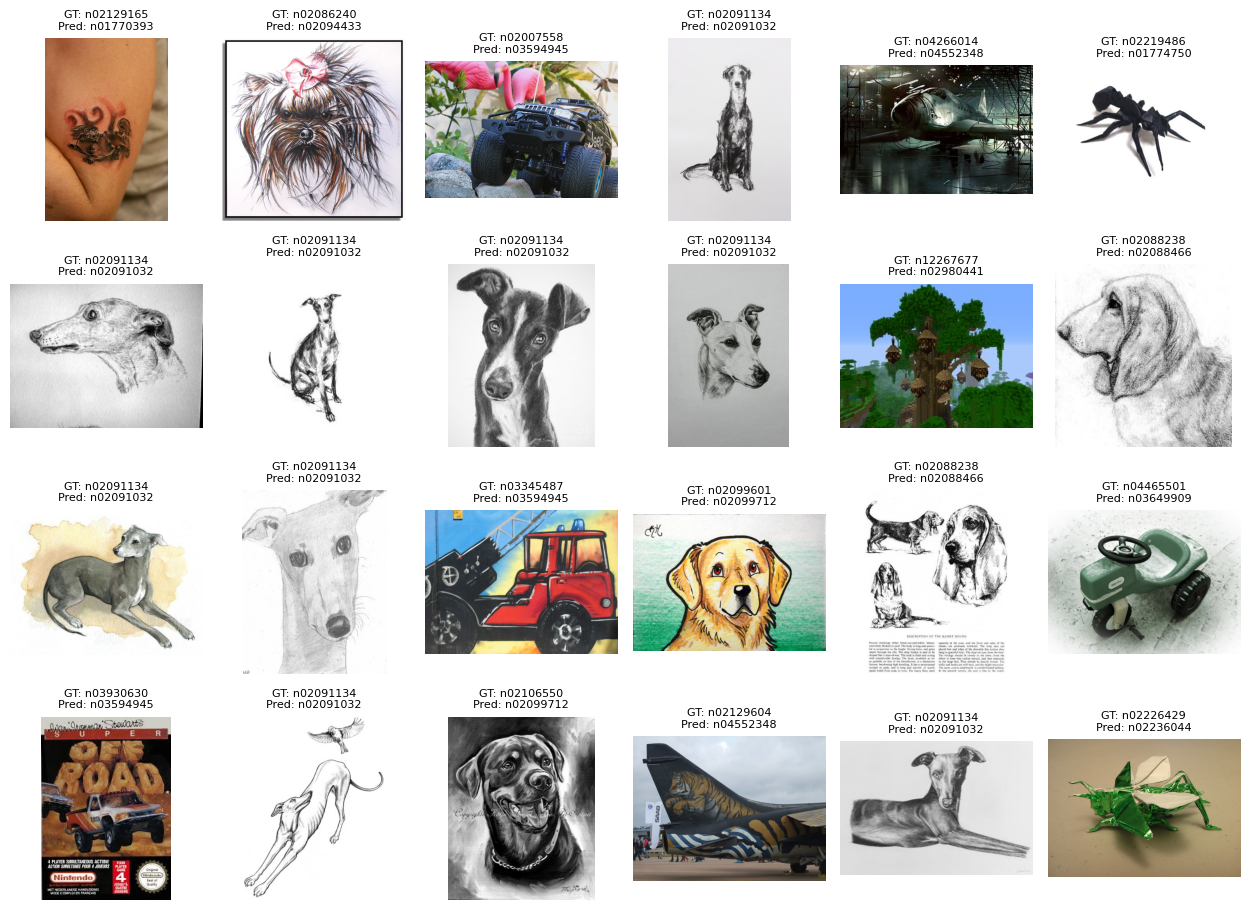

In [19]:

# --- Qualitative: grid of top high-confidence mistakes per model ---
def show_top_errors_grid(df, model_tag, n=24, cols=6, seed=42):
    sub = df[(df.model == model_tag) & (~df.correct)].sort_values(["p_pred","margin"], ascending=False)
    sub = sub.head(n)
    rows = int(math.ceil(len(sub)/cols))
    plt.figure(figsize=(cols*2.1, rows*2.3))
    for i, row in enumerate(sub.itertuples(index=False)):
        ax = plt.subplot(rows, cols, i+1)
        try:
            img = Image.open(row.path).convert("RGB")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Could not load", ha="center")
        ax.set_title(f"GT: {row.y_name}\nPred: {row.y_pred_name}", fontsize=8)
        ax.axis("off")
    plt.tight_layout(); plt.show()

for tag in TAGS:
    print(f"\nHigh-confidence mistakes — {tag}")
    show_top_errors_grid(preds_df, tag, n=24, cols=6)


In [20]:

# --- Confusion pairs (top-K) across models ---
def top_confusion_pairs(df, topk=15):
    wrong = df[~df.correct].copy()
    wrong["pair"] = list(zip(wrong["y_name"], wrong["y_pred_name"]))
    counts = wrong["pair"].value_counts().head(topk)
    for (gt, pr), c in counts.items():
        print(f"{gt}  →  {pr} : {c}")

print("\nTop confusion pairs across all models:")
top_confusion_pairs(preds_df, topk=15)

for tag in TAGS:
    print(f"\nTop confusion pairs — {tag}:")
    top_confusion_pairs(preds_df[preds_df.model==tag], topk=10)



Top confusion pairs across all models:
n02091134  →  n02091032 : 125
n01494475  →  n01484850 : 93
n02480855  →  n02481823 : 79
n02096585  →  n02108915 : 76
n07734744  →  n07745940 : 66
n04086273  →  n02749479 : 65
n02206856  →  n02165456 : 56
n02110958  →  n02108089 : 55
n02226429  →  n02236044 : 53
n02007558  →  n02009912 : 53
n03947888  →  n04147183 : 53
n02130308  →  n02128385 : 52
n07734744  →  n02165456 : 51
n04141076  →  n04487394 : 50
n02206856  →  n02190166 : 50

Top confusion pairs — mambavision_lp:
n02091134  →  n02091032 : 49
n01494475  →  n01484850 : 36
n04086273  →  n02749479 : 33
n07734744  →  n01910747 : 28
n02110958  →  n02108089 : 27
n02129165  →  n02106030 : 26
n04141076  →  n04487394 : 25
n02088238  →  n02088466 : 24
n03947888  →  n04147183 : 24
n02480855  →  n02481823 : 24

Top confusion pairs — vit_b16_lp:
n01494475  →  n01484850 : 34
n02091134  →  n02091032 : 30
n02096585  →  n02108915 : 29
n02480855  →  n02481823 : 27
n07745940  →  n02165456 : 25
n02206856  →  n